Phase 4: Handling Class Imbalance

Step 1: Analyze Class Imbalance

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
X_train = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
)

In [3]:
print("Training Features :", X_train.shape)

print("Training Target :", y_train.shape)

Training Features : (226980, 30)
Training Target : (226980, 1)


In [4]:
y_train.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [5]:
class_counts = y_train["Class"].value_counts()

print(class_counts)

Class
0    226602
1       378
Name: count, dtype: int64


In [6]:
class_percent = (
    y_train["Class"].value_counts(normalize=True)
    * 100
)

print(class_percent)

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


In [7]:
distribution = pd.DataFrame({

    "Class": ["Genuine", "Fraud"],

    "Count": class_counts.values,

    "Percentage": class_percent.values

})

distribution

,Class,Count,Percentage
0,Genuine,226602,99.833466
1,Fraud,378,0.166534


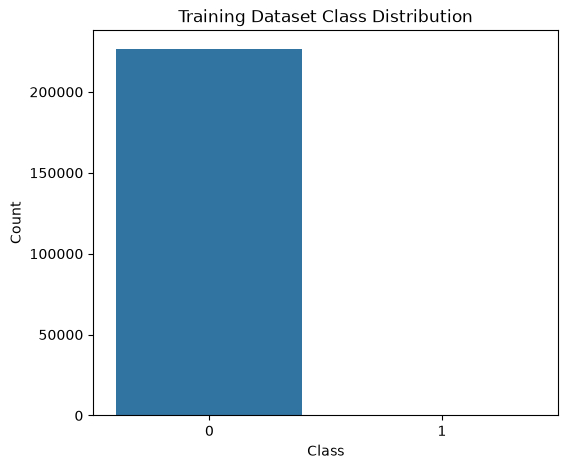

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=y_train["Class"]
)

plt.title("Training Dataset Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.savefig(
    "../images/class_distribution_before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

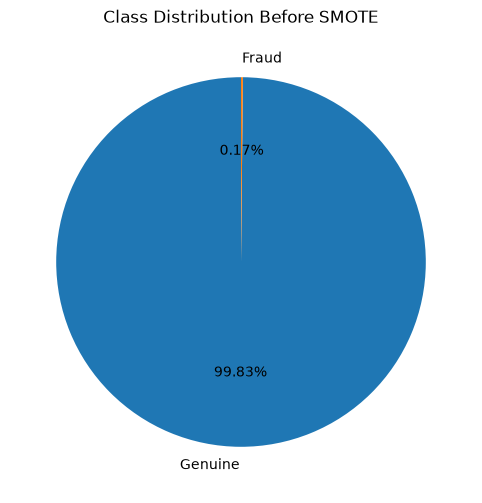

In [9]:
plt.figure(figsize=(6,6))

plt.pie(

    class_counts,

    labels=["Genuine","Fraud"],

    autopct="%1.2f%%",

    startangle=90

)

plt.title("Class Distribution Before SMOTE")

plt.savefig(
    "../images/pie_before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
majority = class_counts[0]

minority = class_counts[1]

ratio = majority / minority

print(f"Imbalance Ratio : {ratio:.2f}:1")

Imbalance Ratio : 599.48:1


In [11]:
distribution.to_csv(
    "../reports/class_distribution_before_smote.csv",
    index=False
)

In [12]:
summary = pd.DataFrame({

    "Metric":[

        "Majority Class",

        "Minority Class",

        "Imbalance Ratio"

    ],

    "Value":[

        class_counts[0],

        class_counts[1],

        ratio

    ]

})

summary.to_csv(

    "../reports/imbalance_summary.csv",

    index=False

)

Step 2: Apply SMOTE (Synthetic Minority Over-sampling Technique)

In [13]:
import pandas as pd

from imblearn.over_sampling import SMOTE

In [14]:
X_train = pd.read_csv(
    "../data/processed/X_train_scaled.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
)

In [15]:
y_train = y_train.squeeze()

In [16]:
print(type(y_train))

<class 'pandas.Series'>


In [17]:
print(type(y_train))

<class 'pandas.Series'>


In [18]:
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

In [19]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [26]:
print("Before SMOTE")

print(X_train.shape)

print(y_train.shape)

print()

print("After SMOTE")

print(X_train_smote.shape)

print(y_train_smote.shape)

Before SMOTE
(226980, 30)
(226980,)

After SMOTE
(453204, 30)
(453204,)


In [21]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [22]:
print(
    y_train_smote.value_counts(normalize=True)*100
)

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [23]:
comparison = pd.DataFrame({

    "Before":[226602,378],

    "After":[226602,226602]

},

index=["Genuine","Fraud"])

comparison

,Before,After
Genuine,226602,226602
Fraud,378,226602


In [24]:
comparison = pd.DataFrame({

    "Before":[226602,378],

    "After":[226602,226602]

},

index=["Genuine","Fraud"])

comparison

,Before,After
Genuine,226602,226602
Fraud,378,226602


In [25]:
summary = pd.DataFrame({

    "Metric":[

        "Original Genuine",

        "Original Fraud",

        "Balanced Genuine",

        "Balanced Fraud"

    ],

    "Value":[

        226602,

        378,

        226602,

        226602

    ]

})

summary.to_csv(
    "../reports/smote_summary.csv",
    index=False
)

In [27]:
X_train_smote.to_csv(
    "../data/processed/X_train_smote.csv",
    index=False
)

In [28]:
y_train_smote.to_csv(
    "../data/processed/y_train_smote.csv",
    index=False
)

Step 3: Verify and Visualize SMOTE Results

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze()

In [31]:
y_train_smote = pd.read_csv(
    "../data/processed/y_train_smote.csv"
).squeeze()

In [32]:
before_counts = y_train.value_counts()

print(before_counts)

Class
0    226602
1       378
Name: count, dtype: int64


In [33]:
after_counts = y_train_smote.value_counts()

print(after_counts)

Class
0    226602
1    226602
Name: count, dtype: int64


In [34]:
comparison = pd.DataFrame({
    "Before SMOTE": before_counts,
    "After SMOTE": after_counts
})

comparison.index = ["Genuine", "Fraud"]

comparison

,Before SMOTE,After SMOTE
Genuine,226602,226602
Fraud,378,226602


In [35]:
before_percentage = (
    before_counts /
    before_counts.sum()
) * 100

print(before_percentage)

Class
0    99.833466
1     0.166534
Name: count, dtype: float64


In [36]:
after_percentage = (
    after_counts /
    after_counts.sum()
) * 100

print(after_percentage)

Class
0    50.0
1    50.0
Name: count, dtype: float64


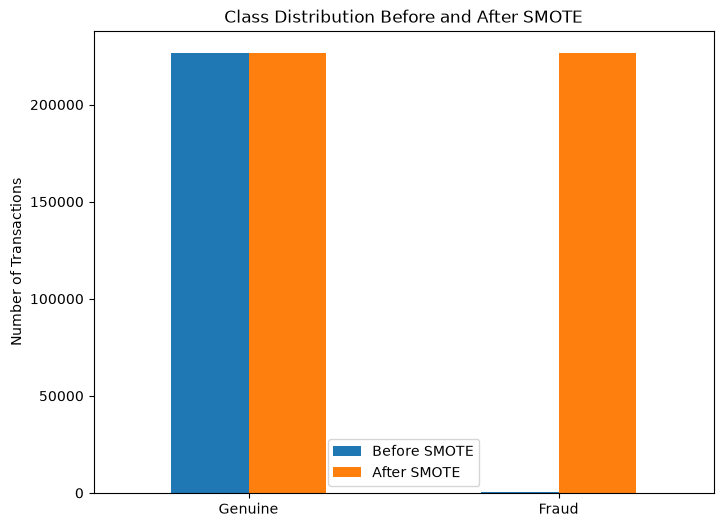

In [37]:
comparison.plot(
    kind="bar",
    figsize=(8,6)
)

plt.title("Class Distribution Before and After SMOTE")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)

plt.savefig(
    "../images/smote_comparison_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

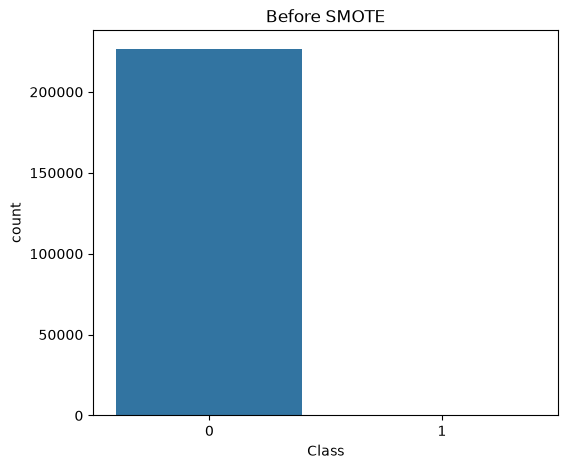

In [38]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_train)

plt.title("Before SMOTE")

plt.savefig(
    "../images/before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

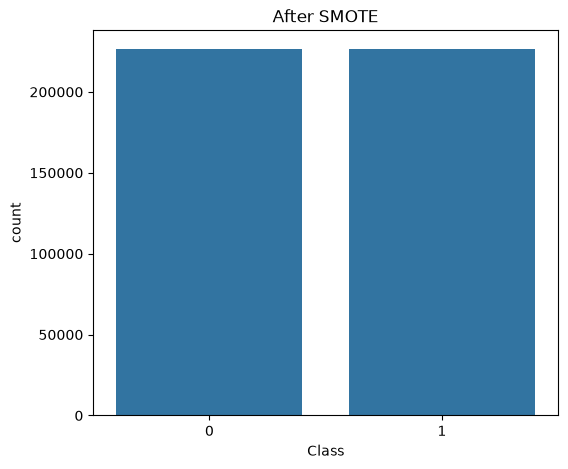

In [39]:
plt.figure(figsize=(6,5))

sns.countplot(x=y_train_smote)

plt.title("After SMOTE")

plt.savefig(
    "../images/after_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

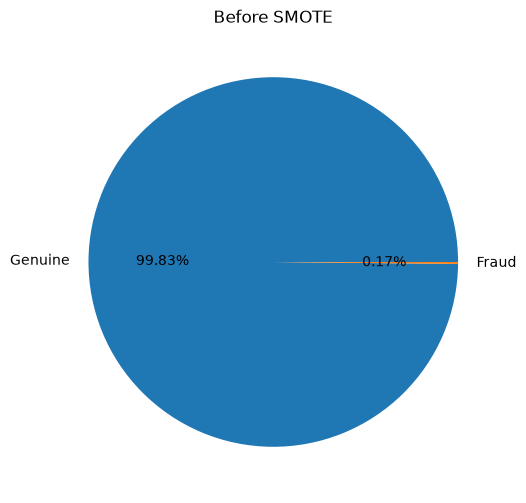

In [40]:
plt.figure(figsize=(6,6))

plt.pie(
    before_counts,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%"
)

plt.title("Before SMOTE")

plt.savefig(
    "../images/pie_before_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

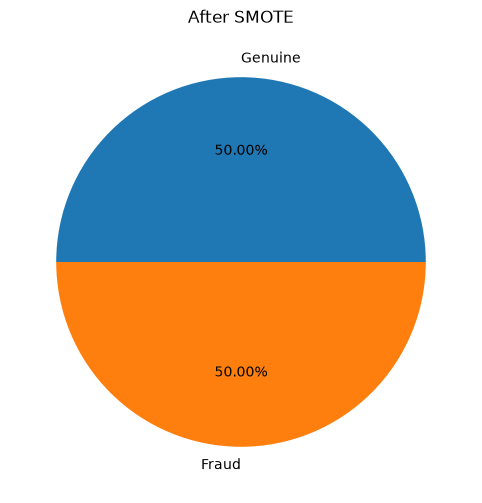

In [41]:
plt.figure(figsize=(6,6))

plt.pie(
    after_counts,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%"
)

plt.title("After SMOTE")

plt.savefig(
    "../images/pie_after_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

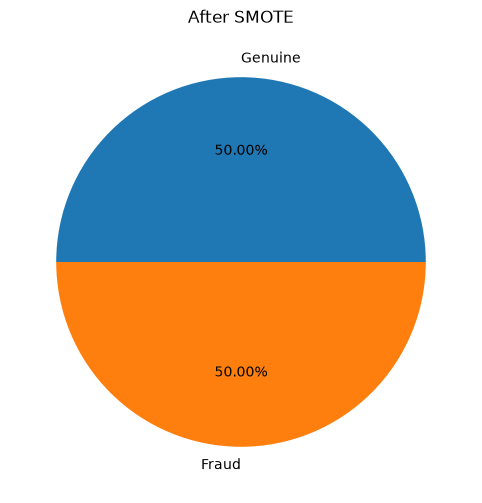

In [42]:
plt.figure(figsize=(6,6))

plt.pie(
    after_counts,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%"
)

plt.title("After SMOTE")

plt.savefig(
    "../images/pie_after_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
print("Before SMOTE:", X_train.shape)

print("After SMOTE:", X_train_smote.shape)

Before SMOTE: (226980, 30)
After SMOTE: (453204, 30)


In [44]:
verification = pd.DataFrame({

    "Class":[
        "Genuine",
        "Fraud"
    ],

    "Before SMOTE": before_counts.values,

    "After SMOTE": after_counts.values,

    "Before %": before_percentage.values,

    "After %": after_percentage.values

})

verification.to_csv(
    "../reports/smote_verification.csv",
    index=False
)

In [45]:
print("="*40)

print("SMOTE VERIFICATION")

print("="*40)

print("Before SMOTE")

print(before_counts)

print()

print("After SMOTE")

print(after_counts)

print()

print("Verification Successful")

print("="*40)

SMOTE VERIFICATION
Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64

Verification Successful


Step 4: Save Final Balanced Dataset and Prepare for Model Training

In [46]:
import pandas as pd
import os

In [47]:
X_train_smote = pd.read_csv(
    "../data/processed/X_train_smote.csv"
)

y_train_smote = pd.read_csv(
    "../data/processed/y_train_smote.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
)

In [48]:
print("Balanced Training Features :", X_train_smote.shape)

print("Balanced Training Labels :", y_train_smote.shape)

print("Testing Features :", X_test.shape)

print("Testing Labels :", y_test.shape)

Balanced Training Features : (453204, 30)
Balanced Training Labels : (453204, 1)
Testing Features : (56746, 30)
Testing Labels : (56746, 1)


In [49]:
print(y_train_smote["Class"].value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [50]:
print(y_test["Class"].value_counts())

Class
0    56651
1       95
Name: count, dtype: int64


In [51]:
print("Training Missing Values")

print(X_train_smote.isnull().sum().sum())

print()

print("Testing Missing Values")

print(X_test.isnull().sum().sum())

Training Missing Values
0

Testing Missing Values
0


In [52]:
print(
    "Training Duplicates:",
    X_train_smote.duplicated().sum()
)

print(
    "Testing Duplicates:",
    X_test.duplicated().sum()
)

Training Duplicates: 0
Testing Duplicates: 0


In [53]:
dataset_info = pd.DataFrame({

    "Dataset":[

        "X_train_smote",

        "y_train_smote",

        "X_test",

        "y_test"

    ],

    "Rows":[

        len(X_train_smote),

        len(y_train_smote),

        len(X_test),

        len(y_test)

    ],

    "Columns":[

        X_train_smote.shape[1],

        y_train_smote.shape[1],

        X_test.shape[1],

        y_test.shape[1]

    ]

})

dataset_info

,Dataset,Rows,Columns
0,X_train_smote,453204,30
1,y_train_smote,453204,1
2,X_test,56746,30
3,y_test,56746,1


In [54]:
dataset_info.to_csv(
    "../reports/final_dataset_summary.csv",
    index=False
)

In [55]:
class_distribution = pd.DataFrame({

    "Dataset":[

        "Training",

        "Training",

        "Testing",

        "Testing"

    ],

    "Class":[

        "Genuine",

        "Fraud",

        "Genuine",

        "Fraud"

    ],

    "Count":[

        y_train_smote["Class"].value_counts()[0],

        y_train_smote["Class"].value_counts()[1],

        y_test["Class"].value_counts()[0],

        y_test["Class"].value_counts()[1]

    ]

})

class_distribution

,Dataset,Class,Count
0,Training,Genuine,226602
1,Training,Fraud,226602
2,Testing,Genuine,56651
3,Testing,Fraud,95


In [56]:
class_distribution.to_csv(
    "../reports/class_distribution_final.csv",
    index=False
)

In [57]:
readiness = pd.DataFrame({

    "Task":[

        "Duplicate Removal",

        "Missing Value Handling",

        "Train-Test Split",

        "Feature Scaling",

        "SMOTE Applied",

        "Verification"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

readiness

,Task,Status
0,Duplicate Removal,Completed
1,Missing Value Handling,Completed
2,Train-Test Split,Completed
3,Feature Scaling,Completed
4,SMOTE Applied,Completed
5,Verification,Completed


In [58]:
readiness.to_csv(
    "../reports/preprocessing_status.csv",
    index=False
)

In [59]:
print("="*50)

print("PHASE 4 COMPLETED SUCCESSFULLY")

print("="*50)

print()

print("Balanced Training Dataset Ready")

print()

print("Testing Dataset Ready")

print()

print("Ready for Machine Learning Models")

print("="*50)

PHASE 4 COMPLETED SUCCESSFULLY

Balanced Training Dataset Ready

Testing Dataset Ready

Ready for Machine Learning Models
